In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('../data/telco.csv')
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [3]:
df.info(
)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  Zip Code                           7043 non-null   int64  
 12  Lat

In [4]:
df.shape

(7043, 50)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
Number of Dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
Zip Code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
Latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
Longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
Population,7043.0,22139.603294,21152.392837,11.000000,2344.000000,17554.000000,36125.000000,105285.000000
Number of Referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
Tenure in Months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
Avg Monthly Long Distance Charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
Avg Monthly GB Download,7043.0,20.515405,20.418940,0.000000,3.000000,17.000000,27.000000,85.000000


In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Churn Reason      5174
Churn Category    5174
Offer             3877
Internet Type     1526
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Features")
print(numerical_cols)

print()

print("Categorical Features")
print(categorical_cols)

Numerical Features
Index(['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV'],
      dtype='str')

Categorical Features
Index(['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Country', 'State', 'City', 'Quarter',
       'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Label',
       'Churn Categor

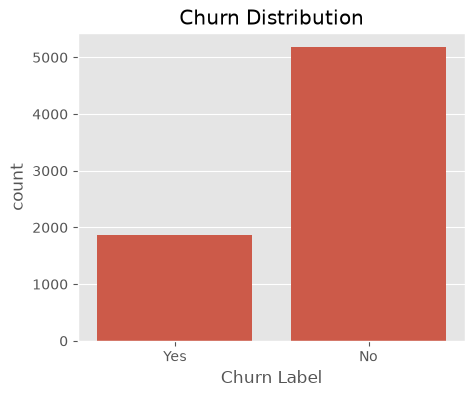

In [9]:
df["Churn Label"].value_counts()
df["Churn Label"].value_counts(normalize=True) * 100
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn Label")
plt.title("Churn Distribution")
plt.show()

In [10]:
# Numerical Feature Summary
numerical_summary = (
    df[numerical_cols]
    .describe()
    .T
    .round(2)
)

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
Age,7043.0,46.51,16.75,19.00,32.00,46.00,60.00,80.00
Number of Dependents,7043.0,0.47,0.96,0.00,0.00,0.00,0.00,9.00
Zip Code,7043.0,93486.07,1856.77,90001.00,92101.00,93518.00,95329.00,96150.00
Latitude,7043.0,36.20,2.47,32.56,33.99,36.21,38.16,41.96
Longitude,7043.0,-119.76,2.15,-124.30,-121.79,-119.60,-117.97,-114.19
Population,7043.0,22139.60,21152.39,11.00,2344.00,17554.00,36125.00,105285.00
Number of Referrals,7043.0,1.95,3.00,0.00,0.00,0.00,3.00,11.00
Tenure in Months,7043.0,32.39,24.54,1.00,9.00,29.00,55.00,72.00
Avg Monthly Long Distance Charges,7043.0,22.96,15.45,0.00,9.21,22.89,36.39,49.99
Avg Monthly GB Download,7043.0,20.52,20.42,0.00,3.00,17.00,27.00,85.00


In [11]:
# Categorical Feature Summary
categorical_summary = pd.DataFrame({
    "Data Type": df[categorical_cols].dtypes,
    "Unique Values": df[categorical_cols].nunique(),
    "Missing Values": df[categorical_cols].isnull().sum()
})

display(categorical_summary)

,Data Type,Unique Values,Missing Values
Customer ID,str,7043,0
Gender,str,2,0
Under 30,str,2,0
Senior Citizen,str,2,0
Married,str,2,0
Dependents,str,2,0
Country,str,1,0
State,str,1,0
City,str,1106,0
Quarter,str,1,0


In [12]:
# Detailed Value Counts
for col in categorical_cols:
    print("=" * 80)
    print(f"Feature: {col}")
    print("=" * 80)

    print(f"Unique Values: {df[col].nunique()}")
    print(f"Missing Values: {df[col].isnull().sum()}")

    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))

    print("\n")

Feature: Customer ID
Unique Values: 7043
Missing Values: 0

Value Counts:
Customer ID
8779-QRDMV    1
7495-OOKFY    1
1658-BYGOY    1
4598-XLKNJ    1
4846-WHAFZ    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64


Feature: Gender
Unique Values: 2
Missing Values: 0

Value Counts:
Gender
Male      3555
Female    3488
Name: count, dtype: int64


Feature: Under 30
Unique Values: 2
Missing Values: 0

Value Counts:
Under 30
No     5642
Yes    1401
Name: count, dtype: int64


Feature: Senior Citizen
Unique Values: 2
Missing Values: 0

Value Counts:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


Feature: Married
Unique Values: 2
Missing Values: 0

Value Counts:
Married
No     3641
Yes    3402
Name: count, dtype: int64


Feature: Dependents
Unique Values: 2
Missing Values: 0

Value Counts:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


Feature: Country
Unique Values: 1
M

In [13]:
# IQR Analysis for Population

Q1 = df["Population"].quantile(0.25)
Q3 = df["Population"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Detect outliers
population_outliers = df[
    (df["Population"] < lower_bound) |
    (df["Population"] > upper_bound)
]

print(f"\nNumber of outliers: {len(population_outliers)}")
print(population_outliers[["Zip Code", "City", "Population"]].sort_values("Population"))

Q1: 2344.0
Q3: 36125.0
IQR: 33781.0
Lower Bound: -48327.5
Upper Bound: 86796.5

Number of outliers: 57
      Zip Code         City  Population
327      90044  Los Angeles       87383
2559     90044  Los Angeles       87383
3618     90044  Los Angeles       87383
4697     90044  Los Angeles       87383
6788     90044  Los Angeles       87383
6084     92683  Westminster       88230
3956     92683  Westminster       88230
2895     92683  Westminster       88230
5026     92683  Westminster       88230
4204     94509      Antioch       90891
2309     94509      Antioch       90891
5274     94509      Antioch       90891
1323     94509      Antioch       90891
3961     92704    Santa Ana       91188
6090     92704    Santa Ana       91188
2901     92704    Santa Ana       91188
5031     92704    Santa Ana       91188
5822     90805   Long Beach       91664
2635     90805   Long Beach       91664
3690     90805   Long Beach       91664
2473     90805   Long Beach       91664
4767     90805   

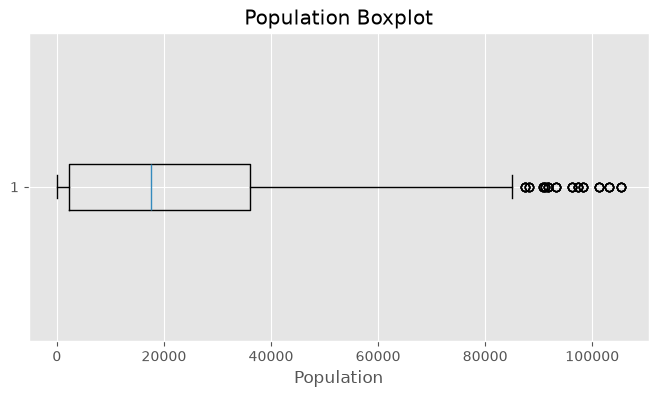

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.boxplot(df["Population"], vert=False)
plt.title("Population Boxplot")
plt.xlabel("Population")
plt.show()

In [15]:
df["Churn Label"].value_counts()
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [18]:
corr = df.corr(numeric_only=True)
print(corr)

                                        Age  Number of Dependents  Zip Code  \
Age                                1.000000             -0.119000 -0.008183   
Number of Dependents              -0.119000              1.000000  0.016493   
Zip Code                          -0.008183              0.016493  1.000000   
Latitude                          -0.010305              0.029081  0.894769   
Longitude                          0.007612             -0.024271 -0.790564   
Population                        -0.018881             -0.015486 -0.424067   
Number of Referrals               -0.025141              0.278003  0.001463   
Tenure in Months                   0.009927              0.108237  0.007146   
Avg Monthly Long Distance Charges -0.011749             -0.007324  0.005894   
Avg Monthly GB Download           -0.376595              0.129966 -0.010998   
Monthly Charge                     0.144685             -0.131837 -0.010775   
Total Charges                      0.059684         

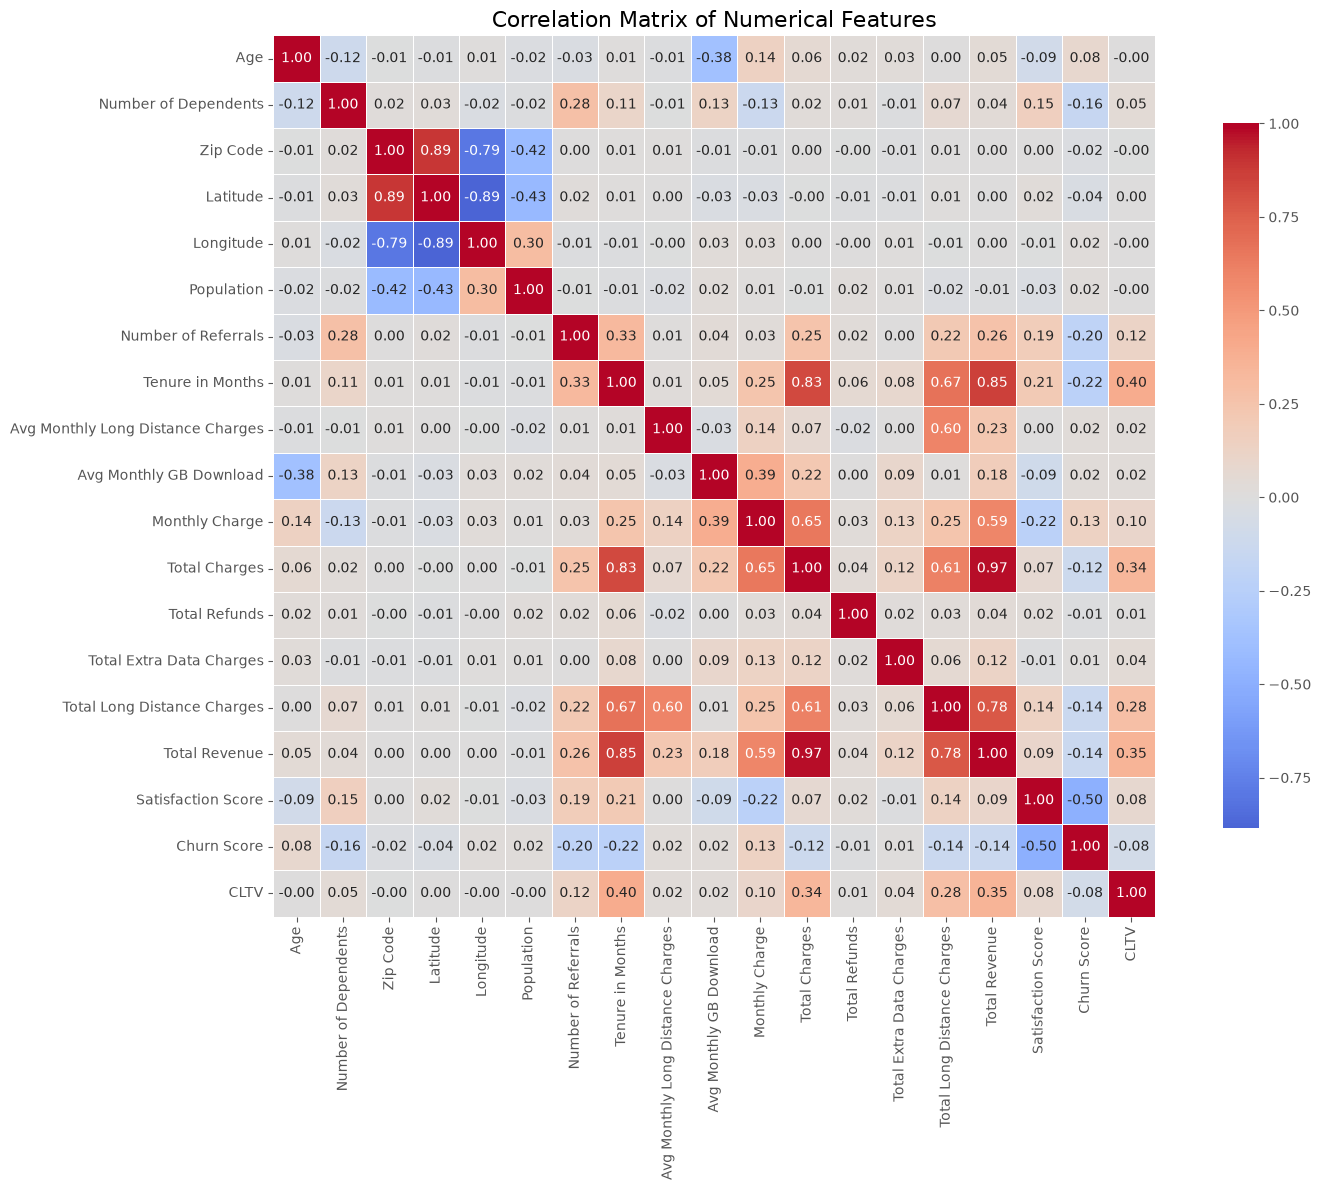

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

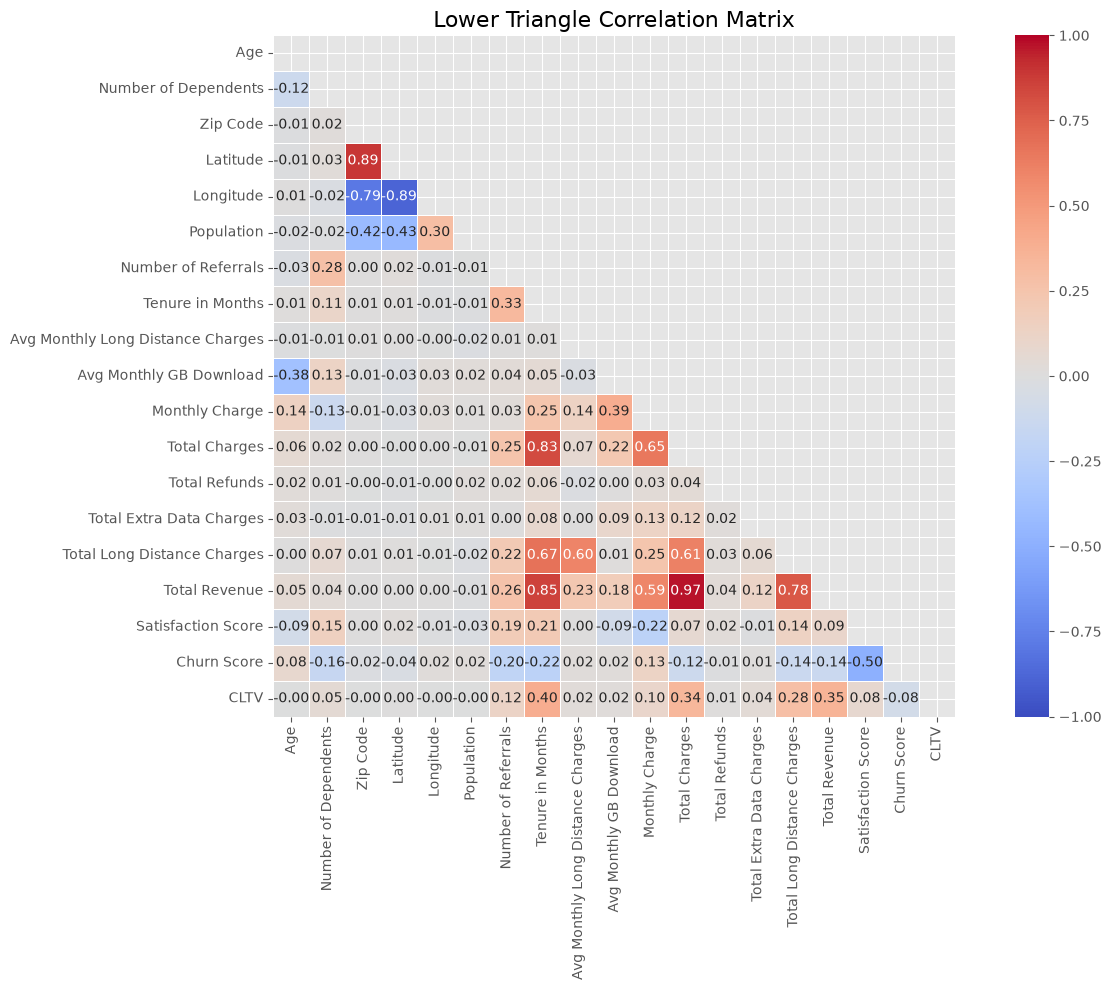

In [21]:
import numpy as np

corr_matrix = df.corr(numeric_only=True)

# Mask the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    vmin=-1,
    vmax=1
)

plt.title("Lower Triangle Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
# Recalculate Total Revenue
df["Calculated_Total_Revenue"] = (
    df["Total Charges"]
    + df["Total Long Distance Charges"]
    + df["Total Extra Data Charges"]
    - df["Total Refunds"]
)

In [23]:
# Check if the calculated value matches the dataset
comparison = df["Total Revenue"] == df["Calculated_Total_Revenue"]

print("Rows matching:", comparison.sum())
print("Rows not matching:", (~comparison).sum())

Rows matching: 6156
Rows not matching: 887


In [24]:
import numpy as np

np.allclose(
    df["Total Revenue"],
    df["Calculated_Total_Revenue"],
    atol=1e-6
)

True